In [ ]:
# %pip install albumentations opencv-python pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import gc
import cv2
import json
import yaml
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score


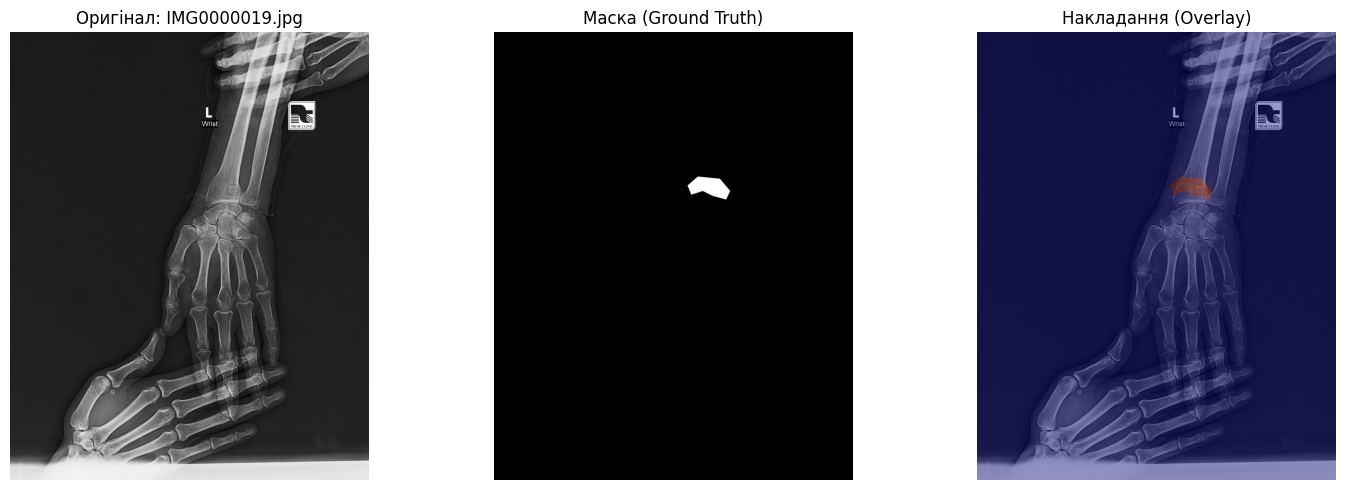

In [3]:
# 1. Вказуємо шляхи до папок
image_dir = '../../multitask-bone-fracture-ai/data/FracAtlas/images/Fractured'

# Увага: перевірте точну назву json-файлу у вашій папці "VGG JSON"
# Він може називатися "VGG_fracture_masks.json", "dataset.json" або подібно
vgg_json_path = '../../multitask-bone-fracture-ai/data/FracAtlas/Annotations/VGG JSON/VGG_fracture_masks.json'

# 2. Відкриваємо файл з координатами масок
with open(vgg_json_path, 'r') as f:
    vgg_data = json.load(f)

# 3. Вибираємо перше-ліпше зображення з JSON
image_key = list(vgg_data.keys())[0]
image_info = vgg_data[image_key]
image_name = image_info['filename']

# 4. Завантажуємо оригінальний рентген
img_path = os.path.join(image_dir, image_name)
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV читає в BGR, переводимо в RGB для Matplotlib

# 5. Створюємо порожню (чорну) маску такого ж розміру, як рентген
mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

# 6. Малюємо полігони (переломи) на нашій чорній масці
regions = image_info.get('regions', [])
# VGG JSON може зберігати регіони як словник або список, обробляємо обидва варіанти
if isinstance(regions, dict):
    regions = list(regions.values())

for region in regions:
    shape = region.get('shape_attributes', {})
    if shape.get('name') == 'polygon':
        # Дістаємо X та Y координати багатокутника
        points_x = shape['all_points_x']
        points_y = shape['all_points_y']

        # Об'єднуємо їх у формат для OpenCV: [[[x1, y1], [x2, y2], ...]]
        polygon_points = np.column_stack((points_x, points_y)).astype(np.int32)

        # Замальовуємо цей багатокутник білим кольором (255)
        cv2.fillPoly(mask, [polygon_points], color=255)

# 7. Будуємо красиву візуалізацію
plt.figure(figsize=(15, 5))

# Оригінальний знімок
plt.subplot(1, 3, 1)
plt.title(f"Оригінал: {image_name}")
plt.imshow(img_rgb)
plt.axis('off')

# Згенерована маска
plt.subplot(1, 3, 2)
plt.title("Маска (Ground Truth)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

# Накладання маски на рентген (Overlay)
plt.subplot(1, 3, 3)
plt.title("Накладання (Overlay)")
plt.imshow(img_rgb)
# Накладаємо маску поверх оригінального знімку (відобразиться як теплова карта)
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 1. Налаштування шляхів з використанням pathlib для зручності
base_dir = Path('../../multitask-bone-fracture-ai/data/FracAtlas')
images_fractured_dir = base_dir / 'images' / 'Fractured'
images_non_fractured_dir = base_dir / 'images' / 'Non_fractured'
vgg_json_path = base_dir / 'Annotations' / 'VGG JSON' / 'VGG_fracture_masks.json'

# Створюємо цільову папку для всіх масок
masks_save_dir = base_dir / 'masks'
masks_save_dir.mkdir(parents=True, exist_ok=True)

# 2. Обробка зображень З ПЕРЕЛОМАМИ (за даними JSON)
print("Генерація масок для знімків з переломами...")
with open(vgg_json_path, 'r') as f:
    vgg_data = json.load(f)

for image_key, image_info in tqdm(vgg_data.items()):
    image_name = image_info['filename']
    img_path = images_fractured_dir / image_name

    # Перевіряємо, чи існує файл фізично
    if not img_path.exists():
        continue

    # Читаємо зображення, щоб дізнатися його оригінальний розмір
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    regions = image_info.get('regions', [])
    if isinstance(regions, dict):
        regions = list(regions.values())

    for region in regions:
        shape = region.get('shape_attributes', {})
        if shape.get('name') == 'polygon':
            points_x = shape['all_points_x']
            points_y = shape['all_points_y']

            # Об'єднуємо координати та малюємо багатокутник
            polygon_points = np.column_stack((points_x, points_y)).astype(np.int32)
            cv2.fillPoly(mask, [polygon_points], color=255)

    # Зберігаємо маску у форматі PNG (важливо для збереження чітких меж 0 і 255)
    mask_filename = img_path.stem + '.png'
    cv2.imwrite(str(masks_save_dir / mask_filename), mask)

# 3. Обробка зображень БЕЗ ПЕРЕЛОМІВ (створення порожніх масок)
print("\nГенерація порожніх масок для здорових знімків...")
# Шукаємо всі файли в папці здорових знімків
non_fractured_images = list(images_non_fractured_dir.glob('*.*'))

for img_path in tqdm(non_fractured_images):
    # Фільтруємо випадкові системні файли
    if img_path.suffix.lower() not in ['.jpg', '.png', '.jpeg']:
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]

    # Для здорових кісток маска повністю чорна (0)
    blank_mask = np.zeros((h, w), dtype=np.uint8)

    mask_filename = img_path.stem + '.png'
    cv2.imwrite(str(masks_save_dir / mask_filename), blank_mask)

print(f"\nГотово! Всі маски (як із переломами, так і порожні) успішно збережені у папку: {masks_save_dir}")

Генерація масок для знімків з переломами...


  1%|          | 4/717 [00:00<01:05, 10.83it/s]

100%|██████████| 717/717 [00:10<00:00, 67.05it/s] 



Генерація порожніх масок для здорових знімків...


  2%|▏         | 63/3366 [00:00<00:26, 122.61it/s]Premature end of JPEG file
Premature end of JPEG file
 19%|█▉        | 643/3366 [00:06<00:29, 90.80it/s] Premature end of JPEG file
Premature end of JPEG file
 43%|████▎     | 1440/3366 [00:12<00:18, 102.17it/s]Premature end of JPEG file
Premature end of JPEG file
 62%|██████▏   | 2078/3366 [00:18<00:08, 144.47it/s]Premature end of JPEG file
Premature end of JPEG file
 81%|████████  | 2719/3366 [00:24<00:06, 100.88it/s]Premature end of JPEG file
Premature end of JPEG file
 84%|████████▍ | 2843/3366 [00:25<00:03, 144.60it/s]Premature end of JPEG file
Premature end of JPEG file
 91%|█████████ | 3059/3366 [00:27<00:02, 124.42it/s]Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
 94%|█████████▎| 3152/3366 [00:28<00:03, 60.39it/s]Premature end of JPEG file
Premature end of JPEG file
100%|██████████| 3366/3366 [00:29<00:00, 112.76it/s]


Готово! Всі маски (як із переломами, так і порожні) успішно збережені у папку: ../../multitask-bone-fracture-ai/data/FracAtlas/masks


In [5]:
class FracAtlasDataset(Dataset):
    """
    Кастомний Dataset для датасету FracAtlas.
    Зчитує image_id зі спліту (train/valid/test) та підтягує мітки з головного dataset.csv.
    """
    def __init__(self, split_csv, dataset_csv, img_dir, mask_dir, transform=None):
        """
        :param split_csv: Шлях до файлу спліту (наприклад, 'train.csv')
        :param dataset_csv: Шлях до загального файлу 'dataset.csv' з усіма мітками
        :param img_dir: Шлях до папки з оригінальними картинками (Fractured + Non_fractured)
        :param mask_dir: Шлях до папки зі згенерованими масками
        :param transform: Об'єкт аугментації (Albumentations)
        """
        # Завантажуємо спліт (тільки імена файлів)
        split_df = pd.read_csv(split_csv)
        # Завантажуємо всі анотації
        full_df = pd.read_csv(dataset_csv)

        # Фільтруємо анотації: залишаємо тільки ті рядки, image_id яких є у нашому спліті
        self.data_frame = full_df[full_df['image_id'].isin(split_df['image_id'])].reset_index(drop=True)

        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Колонки, що відповідають за тип кістки (Multi-label)
        self.bone_classes = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]
        img_name = str(row['image_id'])

        # 1. Мітки типу кістки (Отримуємо масив з 5 значень: [0, 1, 0, 0, 0])
        bone_labels = row[self.bone_classes].values.astype(np.float32)
        bone_tensor = torch.tensor(bone_labels, dtype=torch.float32)

        # 2. Мітка перелому (Одне значення: 0.0 або 1.0)
        fracture_label = float(row['fractured'])
        fracture_tensor = torch.tensor(fracture_label, dtype=torch.float32).unsqueeze(0)

        # 3. Шляхи до файлів
        # Враховуємо, що зображення можуть лежати у двох різних папках
        path_fractured = os.path.join(self.img_dir, 'Fractured', img_name)
        path_non_fractured = os.path.join(self.img_dir, 'Non_fractured', img_name)

        if os.path.exists(path_fractured):
            img_path = path_fractured
        elif os.path.exists(path_non_fractured):
            img_path = path_non_fractured
        else:
            raise FileNotFoundError(f"Зображення {img_name} не знайдено в папках Fractured/Non_fractured")

        # Маски ми зберігали всі в одну папку 'masks' у форматі PNG
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 4. Завантаження картинки
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Помилка читання файлу: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 5. Завантаження маски
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32) # Бінаризація (0 та 1)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

        # 6. Аугментація (спільна для картинки та маски)
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

            # Albumentations повертає маску розмірності (H, W), додаємо канал -> (1, H, W)
            mask = mask.unsqueeze(0)

        return image, bone_tensor, fracture_tensor, mask

# Функції аугментації для тренування та валідації
def get_train_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_segmenter_transforms():
    """
    Трансформації для U-Net.
    Роздільна здатність 512x512, щоб зберегти тонкі лінії переломів.
    """
    return A.Compose([
        A.Resize(512, 512),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_valid_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

In [6]:
# Вказуємо правильні шляхи до твоїх файлів
split_csv_path = '../data/FracAtlas/Utilities/Fracture Split/train.csv'
dataset_csv_path = '../data/FracAtlas/dataset.csv'
img_dir_path = '../data/FracAtlas/images'
mask_dir_path = '../data/FracAtlas/masks'

# Ініціалізуємо наш датасет
train_dataset = FracAtlasDataset(
    split_csv=split_csv_path,
    dataset_csv=dataset_csv_path,
    img_dir=img_dir_path,
    mask_dir=mask_dir_path,
    transform=get_train_transforms()
)

# Створюємо DataLoader (беремо 4 картинки за раз)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Беремо один тестовий батч
images, bone_labels, fracture_labels, masks = next(iter(train_loader))

# Виводимо розмірності тензорів
print(f"Тензор зображень: {images.shape}")
print(f"Тензор типу кісток (Multi-label): {bone_labels.shape}")
print(f"Тензор наявності перелому: {fracture_labels.shape}")
print(f"Тензор масок сегментації: {masks.shape}")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Тензор зображень: torch.Size([4, 3, 224, 224])
Тензор типу кісток (Multi-label): torch.Size([4, 5])
Тензор наявності перелому: torch.Size([4, 1])
Тензор масок сегментації: torch.Size([4, 1, 224, 224])


In [7]:
# ==========================================
# 1. МУЛЬТИЗАДАЧНИЙ КЛАСИФІКАТОР (Етап скринінгу)
# ==========================================
class MultiTaskClassifier(nn.Module):
    """
    Мультизадачна модель на базі ResNet50 для одночасного
    визначення типу кістки та наявності перелому.
    """
    def __init__(self, num_bone_classes=5):
        super(MultiTaskClassifier, self).__init__()

        # Завантажуємо попередньо навчену ResNet50 (Transfer Learning)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # Відрізаємо останній шар (fc), залишаючи лише екстрактор ознак
        # Це відповідає формулі: f = backbone(x), де f ∈ R^2048
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        in_features = resnet.fc.in_features # 2048

        # Task-specific гілки (Heads)
        self.bone_head = nn.Linear(in_features, num_bone_classes)
        self.fracture_head = nn.Linear(in_features, 1)

    def forward(self, x):
        # 1. Витягуємо ознаки (Feature extraction)
        f = self.backbone(x)
        f = torch.flatten(f, 1) # Згладжуємо тензор [B, 2048, 1, 1] у [B, 2048]

        # 2. Пропускаємо через голови
        logits_bone = self.bone_head(f)
        logits_fracture = self.fracture_head(f)

        return logits_bone, logits_fracture


# ==========================================
# 2. СЕГМЕНТАЦІЙНА МОДЕЛЬ U-NET (Етап деталізації)
# ==========================================
class DoubleConv(nn.Module):
    """(Conv2D -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class FractureSegmenter(nn.Module):
    """
    Класична архітектура U-Net для семантичної сегментації переломів.
    """
    def __init__(self, in_channels=3, out_channels=1):
        super(FractureSegmenter, self).__init__()

        # --- Енкодер (Контрактивний шлях) ---
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # --- Центральний блок (Bottleneck) ---
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # --- Декодер (Розширювальний шлях зі Skip-connections) ---
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        # Фінальний шар генерує 1 канал (маску)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Прямий прохід через енкодер (зберігаємо проміжні стани для skip-connections)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Прямий прохід через декодер + конкатенація
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv4(x)

        # Отримуємо логіти маски (без сигмоїди, оскільки вона буде у функції втрат BCEWithLogitsLoss)
        logits_mask = self.outc(x)
        return logits_mask

In [8]:
# ==========================================
# 1. ФУНКЦІЇ ВТРАТ (Loss Functions)
# ==========================================

class MultiTaskLoss(nn.Module):
    """
    Зважена сума функцій втрат для мультизадачного класифікатора.
    L_total = lambda1 * L_bone + lambda2 * L_fracture
    """
    def __init__(self, lambda_bone=1.0, lambda_fracture=2.0):
        super().__init__()
        self.lambda_bone = lambda_bone
        self.lambda_fracture = lambda_fracture
        # Використовуємо BCEWithLogitsLoss для обох задач,
        # оскільки тип кістки - це Multi-label, а перелом - бінарна класифікація
        self.bce_bone = nn.BCEWithLogitsLoss()
        self.bce_fracture = nn.BCEWithLogitsLoss()

    def forward(self, logits_bone, targets_bone, logits_fracture, targets_fracture):
        loss_bone = self.bce_bone(logits_bone, targets_bone)
        loss_fracture = self.bce_fracture(logits_fracture, targets_fracture)
        return (self.lambda_bone * loss_bone) + (self.lambda_fracture * loss_fracture)


class DiceBCELoss(nn.Module):
    """
    Комбінована функція втрат для сегментації (U-Net).
    L_seg = BCE + (1 - Dice)
    """
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits_mask, targets_mask, smooth=1e-6):
        # 1. Binary Cross-Entropy Loss
        bce_loss = self.bce(logits_mask, targets_mask)

        # 2. Dice Loss
        # Застосовуємо сигмоїду, щоб перевести логіти у ймовірності [0, 1]
        probs = torch.sigmoid(logits_mask)

        # Витягуємо тензори в один рядок для зручного розрахунку перетину
        probs_flat = probs.view(-1)
        targets_flat = targets_mask.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + smooth) / (probs_flat.sum() + targets_flat.sum() + smooth)
        dice_loss = 1.0 - dice_score

        return bce_loss + dice_loss


# ==========================================
# 2. ЦИКЛ НАВЧАННЯ (Trainer)
# ==========================================

def train_classifier_epoch(model, dataloader, criterion, optimizer, device):
    """
    Тренування мультизадачного класифікатора протягом однієї епохи з підрахунком метрик.
    """
    model.train()
    running_loss = 0.0

    # Списки для накопичення результатів по всій епосі
    all_frac_preds, all_frac_targets = [], []
    all_bone_preds, all_bone_targets = [], []

    pbar = tqdm(dataloader, desc="Training Classifier", leave=False)

    for batch in pbar:
        images, bone_labels, fracture_labels, _ = batch

        images = images.to(device)
        bone_labels = bone_labels.to(device)
        fracture_labels = fracture_labels.to(device)

        optimizer.zero_grad()
        logits_bone, logits_fracture = model(images)
        loss = criterion(logits_bone, bone_labels, logits_fracture, fracture_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # --- ЗБІР ДАНИХ ДЛЯ МЕТРИК ---
        # Пропускаємо логіти через сигмоїду і застосовуємо поріг 0.5
        with torch.no_grad():
            # 1. Для переломів
            frac_preds = (torch.sigmoid(logits_fracture) > 0.5).cpu().numpy()
            all_frac_preds.extend(frac_preds)
            all_frac_targets.extend(fracture_labels.cpu().numpy())

            # 2. Для типу кістки
            bone_preds = (torch.sigmoid(logits_bone) > 0.5).cpu().numpy()
            all_bone_preds.extend(bone_preds)
            all_bone_targets.extend(bone_labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)

    # --- РОЗРАХУНОК МЕТРИК ---
    # zero_division=0 уникає помилок на перших епохах, коли модель може видавати суцільні нулі
    metrics = {
        'loss': epoch_loss,
        'frac_recall': recall_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_f1': f1_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_acc': accuracy_score(all_frac_targets, all_frac_preds),
        # Використовуємо average='macro' для Multi-label класифікації кісток
        'bone_f1': f1_score(all_bone_targets, all_bone_preds, average='macro', zero_division=0)
    }

    return metrics

In [9]:
def train_segmenter_epoch(model, dataloader, criterion, optimizer, device):
    """
    Тренування сегментаційної моделі (U-Net) протягом однієї епохи.
    Навчається лише на знімках, де Є перелом (D_frac).
    """
    model.train()
    running_loss = 0.0

    # Змінні для накопичення метрик
    epoch_dice = 0.0
    epoch_iou = 0.0
    batches_count = 0 # Лічильник батчів, у яких були переломи

    pbar = tqdm(dataloader, desc="Training Segmenter", leave=False)

    for batch in pbar:
        images, _, fracture_labels, masks = batch

        # --- ФІЛЬТРАЦІЯ D_frac ---
        # Знаходимо індекси картинок, де fracture_label == 1.0 (є перелом)
        is_fractured = (fracture_labels.view(-1) == 1.0)

        # Якщо в поточному батчі взагалі немає переломів - пропускаємо його
        if not is_fractured.any():
            continue

        # Залишаємо тільки знімки з переломами та їхні маски
        images = images[is_fractured].to(device)
        masks = masks[is_fractured].to(device)

        # 1. Обнуляємо градієнти
        optimizer.zero_grad()

        # 2. Прямий прохід
        logits_mask = model(images)

        # 3. Рахуємо помилку (Dice + BCE)
        loss = criterion(logits_mask, masks)

        # 4. Зворотне поширення та крок оптимізатора
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # --- РОЗРАХУНОК МЕТРИК DSC та IoU ---
        with torch.no_grad():
            # Переводимо логіти у бінарну маску
            preds = (torch.sigmoid(logits_mask) > 0.5).float()

            # Рахуємо перетин (Intersection) та об'єднання (Union) для кожного знімка в батчі
            # Розмірності: [B, 1, H, W] -> сумуємо по каналах, висоті та ширині (dim=(1,2,3))
            intersection = (preds * masks).sum(dim=(1, 2, 3))
            union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

            # Додаємо smooth (1e-6), щоб уникнути ділення на нуль
            smooth = 1e-6
            iou = (intersection + smooth) / (union + smooth)
            dice = (2. * intersection + smooth) / (preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) + smooth)

            # Додаємо середнє значення по батчу до загальної суми
            epoch_iou += iou.mean().item()
            epoch_dice += dice.mean().item()
            batches_count += 1

        pbar.set_postfix({'loss': loss.item()})

    # Повертаємо усереднені метрики (захист від ділення на 0, якщо переломів не було взагалі)
    if batches_count > 0:
        return {
            'loss': running_loss / batches_count,
            'dice': epoch_dice / batches_count,
            'iou': epoch_iou / batches_count
        }
    else:
        return {'loss': 0, 'dice': 0, 'iou': 0}

In [10]:
def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)


# 1. Завантаження конфігурації
config = load_config('../configs/config.yaml')

# Визначення пристрою (GPU чи CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск навчання на: {device}")

# 2. Ініціалізація датасету та DataLoader
print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_train_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['classifier']['batch_size'],
    shuffle=True,
    num_workers=min(8, os.cpu_count() or 1)
)

# 3. Ініціалізація моделі (Етап 1: Класифікатор)
print("🧠 Ініціалізація моделі MultiTaskClassifier...")
model = MultiTaskClassifier(num_bone_classes=5).to(device)

# 4. Визначення функції втрат та оптимізатора
# Згідно з математичним описом, використовуємо Adam optimizer
criterion = MultiTaskLoss(lambda_bone=1.0, lambda_fracture=2.0).to(device)
optimizer = optim.Adam(model.parameters(), lr=config['classifier']['learning_rate'])

# 5. Цикл навчання
num_epochs = config['classifier']['num_epochs']
print(f"🔥 Починаємо тренування на {num_epochs} епох...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Епоха {epoch}/{num_epochs} ---")

    # Запускаємо нашу функцію з trainer.py (тепер вона повертає словник metrics)
    metrics = train_classifier_epoch(model, train_loader, criterion, optimizer, device)

    # Красивий вивід метрик
    print(f"✅ Loss: {metrics['loss']:.4f}")
    print(f"   🦴 Bone F1 (Multi-label): {metrics['bone_f1']:.4f}")
    print(f"   ⚡ Fracture Recall:       {metrics['frac_recall']:.4f}")
    print(f"   ⚡ Fracture F1-score:     {metrics['frac_f1']:.4f}")

print("\n🎉 Тренування класифікатора завершено!")

# Збереження ваг моделі
torch.save(model.state_dict(), "multitask_classifier.pth")
print("💾 Ваги моделі збережено у файл 'multitask_classifier.pth'")

🚀 Запуск навчання на: cuda
📦 Завантаження даних...
🧠 Ініціалізація моделі MultiTaskClassifier...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/zeus/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s] 


🔥 Починаємо тренування на 5 епох...

--- Епоха 1/5 ---


✅ Loss: 0.5458
   🦴 Bone F1 (Multi-label): 0.3626
   ⚡ Fracture Recall:       0.9756
   ⚡ Fracture F1-score:     0.9877

--- Епоха 2/5 ---


✅ Loss: 0.1817
   🦴 Bone F1 (Multi-label): 0.8435
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000

--- Епоха 3/5 ---


✅ Loss: 0.1256
   🦴 Bone F1 (Multi-label): 0.8604
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000

--- Епоха 4/5 ---


✅ Loss: 0.1149
   🦴 Bone F1 (Multi-label): 0.8719
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000

--- Епоха 5/5 ---


✅ Loss: 0.1003
   🦴 Bone F1 (Multi-label): 0.8901
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000

🎉 Тренування класифікатора завершено!
💾 Ваги моделі збережено у файл 'multitask_classifier.pth'


In [ ]:
# Примусове очищення пам'яті перед стартом
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)


# 1. Завантаження конфігурації
config = load_config('../configs/config.yaml')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск навчання сегментатора на: {device}")

# 2. Ініціалізація датасету
print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=min(8, os.cpu_count() or 1) # Залишаємо 0 для стабільності на Windows
)

# 3. Ініціалізація моделі (Етап 2: U-Net)
print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# 4. Визначення функції втрат та оптимізатора
criterion = DiceBCELoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=config['segmenter']['learning_rate'])

# 5. Цикл навчання
num_epochs = config['segmenter']['num_epochs']
print(f"🔥 Починаємо тренування сегментатора на {num_epochs} епох...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Епоха {epoch}/{num_epochs} ---")

    # Запускаємо функцію тренування сегментатора
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)

    print(f"✅ Loss: {metrics['loss']:.4f}")
    print(f"   🎯 Dice Score: {metrics['dice']:.4f}")
    print(f"   🎯 IoU Score:  {metrics['iou']:.4f}")

print("\n🎉 Тренування U-Net завершено!")

# # Збереження ваг моделі
# torch.save(model.state_dict(), "fracture_segmenter.pth")
# print("💾 Ваги моделі збережено у файл 'fracture_segmenter.pth'")

# Збереження ваг моделі
torch.save(model.state_dict(), "fracture_segmenter_v2.pth")
print("💾 Ваги моделі збережено у файл 'fracture_segmenter_v2.pth'")

🚀 Запуск навчання сегментатора на: cuda
📦 Завантаження даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...
🔥 Починаємо тренування сегментатора на 50 епох...

--- Епоха 1/50 ---


✅ Loss: 1.2493
   🎯 Dice Score: 0.0007
   🎯 IoU Score:  0.0003

--- Епоха 2/50 ---


✅ Loss: 1.1115
   🎯 Dice Score: 0.0000
   🎯 IoU Score:  0.0000

--- Епоха 3/50 ---


✅ Loss: 1.0648
   🎯 Dice Score: 0.0000
   🎯 IoU Score:  0.0000

--- Епоха 4/50 ---


✅ Loss: 1.0412
   🎯 Dice Score: 0.0000
   🎯 IoU Score:  0.0000

--- Епоха 5/50 ---


...

✅ Loss: 0.6668
   🎯 Dice Score: 0.2934
   🎯 IoU Score:  0.2092

--- Епоха 47/50 ---


✅ Loss: 0.6541
   🎯 Dice Score: 0.2961
   🎯 IoU Score:  0.2142

--- Епоха 48/50 ---


✅ Loss: 0.6627
   🎯 Dice Score: 0.2952
   🎯 IoU Score:  0.2128

--- Епоха 49/50 ---


✅ Loss: 0.6516
   🎯 Dice Score: 0.3002
   🎯 IoU Score:  0.2163

--- Епоха 50/50 ---


✅ Loss: 0.6214
   🎯 Dice Score: 0.3200
   🎯 IoU Score:  0.2328

🎉 Тренування U-Net завершено!
💾 Ваги моделі збережено у файл 'fracture_segmenter_v2.pth'


In [ ]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=min(8, os.cpu_count() or 1) 
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v2.pth", map_location=device))
print("♻️ Попередні ваги (v2) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.0005 
optimizer = optim.Adam(model.parameters(), lr=new_lr)

# Поставимо ще 50 епох
num_epochs = 50 
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)
    
    print(f"✅ Loss: {metrics['loss']:.4f}")
    print(f"   🎯 Dice Score: {metrics['dice']:.4f}")
    print(f"   🎯 IoU Score:  {metrics['iou']:.4f}")

print("\n🎉 Додаткове тренування завершено!")

# Зберігаємо під новим іменем, щоб мати бекап попередньої версії
torch.save(model.state_dict(), "fracture_segmenter_v3.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v3.pth'")

📦 Завантаження даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...
♻️ Попередні ваги (v2) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.0005...

--- Додаткова Епоха 1/50 ---


✅ Loss: 0.6308
   🎯 Dice Score: 0.3143
   🎯 IoU Score:  0.2292

--- Додаткова Епоха 2/50 ---


✅ Loss: 0.6280
   🎯 Dice Score: 0.3225
   🎯 IoU Score:  0.2365

--- Додаткова Епоха 3/50 ---


✅ Loss: 0.6045
   🎯 Dice Score: 0.3347
   🎯 IoU Score:  0.2463

--- Додаткова Епоха 4/50 ---


✅ Loss: 0.6188
   🎯 Dice Score: 0.3250
   🎯 IoU Score:  0.2390

--- Додаткова Епоха 5/50 ---


...

✅ Loss: 0.4605
   🎯 Dice Score: 0.4459
   🎯 IoU Score:  0.3447

--- Додаткова Епоха 47/50 ---


✅ Loss: 0.4532
   🎯 Dice Score: 0.4435
   🎯 IoU Score:  0.3440

--- Додаткова Епоха 48/50 ---


✅ Loss: 0.4615
   🎯 Dice Score: 0.4435
   🎯 IoU Score:  0.3416

--- Додаткова Епоха 49/50 ---


✅ Loss: 0.4454
   🎯 Dice Score: 0.4471
   🎯 IoU Score:  0.3496

--- Додаткова Епоха 50/50 ---


✅ Loss: 0.4386
   🎯 Dice Score: 0.4638
   🎯 IoU Score:  0.3600

🎉 Додаткове тренування завершено!
💾 Нові ваги збережено у файл 'fracture_segmenter_v3.pth'


In [ ]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=min(8, os.cpu_count() or 1) 
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v3.pth", map_location=device))
print("♻️ Попередні ваги (v3) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.0005 
optimizer = optim.Adam(model.parameters(), lr=new_lr)

# Поставимо ще 50 епох
num_epochs = 50 
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)
    
    print(f"✅ Loss: {metrics['loss']:.4f}")
    print(f"   🎯 Dice Score: {metrics['dice']:.4f}")
    print(f"   🎯 IoU Score:  {metrics['iou']:.4f}")

print("\n🎉 Додаткове тренування завершено!")

# Зберігаємо під новим іменем, щоб мати бекап попередньої версії
torch.save(model.state_dict(), "fracture_segmenter_v4.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v4.pth'")

📦 Завантаження даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...
♻️ Попередні ваги (v3) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.0005...

--- Додаткова Епоха 1/50 ---


✅ Loss: 0.4442
   🎯 Dice Score: 0.4465
   🎯 IoU Score:  0.3464

--- Додаткова Епоха 2/50 ---


✅ Loss: 0.4393
   🎯 Dice Score: 0.4590
   🎯 IoU Score:  0.3555

--- Додаткова Епоха 3/50 ---


✅ Loss: 0.4356
   🎯 Dice Score: 0.4559
   🎯 IoU Score:  0.3566

--- Додаткова Епоха 4/50 ---


✅ Loss: 0.4259
   🎯 Dice Score: 0.4552
   🎯 IoU Score:  0.3556

--- Додаткова Епоха 5/50 ---


...

✅ Loss: 0.3311
   🎯 Dice Score: 0.5519
   🎯 IoU Score:  0.4493

--- Додаткова Епоха 47/50 ---


✅ Loss: 0.3128
   🎯 Dice Score: 0.5721
   🎯 IoU Score:  0.4678

--- Додаткова Епоха 48/50 ---


✅ Loss: 0.3182
   🎯 Dice Score: 0.5642
   🎯 IoU Score:  0.4611

--- Додаткова Епоха 49/50 ---


✅ Loss: 0.3287
   🎯 Dice Score: 0.5607
   🎯 IoU Score:  0.4558

--- Додаткова Епоха 50/50 ---


✅ Loss: 0.3223
   🎯 Dice Score: 0.5569
   🎯 IoU Score:  0.4518

🎉 Додаткове тренування завершено!
💾 Нові ваги збережено у файл 'fracture_segmenter_v4.pth'


In [ ]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=min(8, os.cpu_count() or 1)
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v4.pth", map_location=device))
print("♻️ Попередні ваги (v4) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.00025
optimizer = optim.Adam(model.parameters(), lr=new_lr)

# Поставимо ще 50 епох
num_epochs = 50
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)

    print(f"✅ Loss: {metrics['loss']:.4f}")
    print(f"   🎯 Dice Score: {metrics['dice']:.4f}")
    print(f"   🎯 IoU Score:  {metrics['iou']:.4f}")

print("\n🎉 Додаткове тренування завершено!")

# Зберігаємо під новим іменем, щоб мати бекап попередньої версії
torch.save(model.state_dict(), "fracture_segmenter_v5.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v5.pth'")

📦 Завантаження даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...
♻️ Попередні ваги (v4) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.00025...

--- Додаткова Епоха 1/50 ---


✅ Loss: 0.3077
   🎯 Dice Score: 0.5706
   🎯 IoU Score:  0.4696

--- Додаткова Епоха 2/50 ---


✅ Loss: 0.2895
   🎯 Dice Score: 0.5974
   🎯 IoU Score:  0.4951

--- Додаткова Епоха 3/50 ---


✅ Loss: 0.2915
   🎯 Dice Score: 0.5971
   🎯 IoU Score:  0.4945

--- Додаткова Епоха 4/50 ---


✅ Loss: 0.2848
   🎯 Dice Score: 0.6101
   🎯 IoU Score:  0.5068

--- Додаткова Епоха 5/50 ---


...

✅ Loss: 0.2328
   🎯 Dice Score: 0.6580
   🎯 IoU Score:  0.5638

--- Додаткова Епоха 47/50 ---


✅ Loss: 0.2293
   🎯 Dice Score: 0.6639
   🎯 IoU Score:  0.5675

--- Додаткова Епоха 48/50 ---


✅ Loss: 0.2277
   🎯 Dice Score: 0.6679
   🎯 IoU Score:  0.5705

--- Додаткова Епоха 49/50 ---


✅ Loss: 0.2304
   🎯 Dice Score: 0.6623
   🎯 IoU Score:  0.5690

--- Додаткова Епоха 50/50 ---


✅ Loss: 0.2244
   🎯 Dice Score: 0.6653
   🎯 IoU Score:  0.5697

🎉 Додаткове тренування завершено!
💾 Нові ваги збережено у файл 'fracture_segmenter_v5.pth'


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск тестування на: {device}")

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')

# ---------------------------------------------------------
# 1. ТРАНСФОРМАЦІЇ ДЛЯ ТЕСТУ (БЕЗ АУГМЕНТАЦІЙ!)
# ---------------------------------------------------------
# На тесті ми не робимо поворотів чи змін контрасту, лише розмір і нормалізацію
test_transform_cls = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_transform_seg = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ---------------------------------------------------------
# 2. ТЕСТУВАННЯ КЛАСИФІКАТОРА (Етап 1)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🦴 ЕТАП 1: Тестування MultiTaskClassifier")
print("="*50)

test_dataset_cls = FracAtlasDataset(
    split_csv=config['data']['test_split'], 
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=test_transform_cls
)

test_loader_cls = DataLoader(test_dataset_cls, batch_size=config['classifier']['batch_size'], shuffle=False, num_workers=4)

classifier = MultiTaskClassifier(num_bone_classes=5).to(device)
classifier.load_state_dict(torch.load('multitask_classifier.pth', map_location=device))
classifier.eval()

all_frac_labels = []
all_frac_preds = []

with torch.no_grad():
    for images, labels_bone, labels_frac, _ in tqdm(test_loader_cls, desc="Тестування класифікатора"):
        images = images.to(device)
        labels_frac = labels_frac.float().to(device)
        
        _, logits_fracture = classifier(images)
        probs_fracture = torch.sigmoid(logits_fracture).squeeze(-1)
        preds_fracture = (probs_fracture > 0.5).float()
        
        all_frac_labels.extend(labels_frac.cpu().numpy())
        all_frac_preds.extend(preds_fracture.cpu().numpy())

# Рахуємо метрики для класифікатора
recall = recall_score(all_frac_labels, all_frac_preds)
precision = precision_score(all_frac_labels, all_frac_preds, zero_division=0)
f1 = f1_score(all_frac_labels, all_frac_preds)
acc = accuracy_score(all_frac_labels, all_frac_preds)

print(f"\n📊 Результати класифікації переломів на Test Set:")
print(f"  🔹 Accuracy:  {acc:.4f}")
print(f"  🔹 Precision: {precision:.4f} (наскільки ми праві, коли кажемо 'перелом')")
print(f"  🔹 Recall:    {recall:.4f} (скільки реальних переломів ми знайшли)")
print(f"  🔹 F1-Score:  {f1:.4f} (баланс)")

# ---------------------------------------------------------
# 3. ТЕСТУВАННЯ СЕГМЕНТАТОРА (Етап 2)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🩸 ЕТАП 2: Тестування FractureSegmenter (v5)")
print("="*50)

test_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['test_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=test_transform_seg
)

# Для сегментатора батч може бути меншим (як під час тренування)
test_loader_seg = DataLoader(test_dataset_seg, batch_size=config['segmenter']['batch_size'], shuffle=False, num_workers=4)

segmenter = FractureSegmenter(in_channels=3, out_channels=1).to(device)
segmenter.load_state_dict(torch.load('fracture_segmenter_v4.pth', map_location=device))
segmenter.eval()

criterion_seg = DiceBCELoss().to(device)
total_dice = 0.0
total_iou = 0.0
batches = 0

with torch.no_grad():
    for images, _, labels_frac, masks in tqdm(test_loader_seg, desc="Тестування сегментатора"):
        images = images.to(device)
        masks = masks.float().to(device)
        
        # Запускаємо модель
        logits_mask = segmenter(images)
        
        # Обчислюємо метрики через твою ж функцію втрат (DiceBCELoss)
        # У ній ми маємо доступ до Dice та IoU. Оскільки ми не маємо прямого доступу до них
        # ззовні, ми можемо переписати логіку розрахунку вручну:
        
        probs = torch.sigmoid(logits_mask)
        preds = (probs > 0.5).float()
        
        # Рахуємо перетин (Intersection) та об'єднання (Union) для батчу
        intersection = (preds * masks).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) - intersection
        
        # Dice: (2 * Intersection) / (Pred_Area + True_Area)
        dice = (2.0 * intersection) / (preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) + 1e-7)
        
        # IoU: Intersection / Union
        iou = intersection / (union + 1e-7)
        
        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        batches += 1

print(f"\n📊 Результати сегментації переломів на Test Set:")
print(f"  🎯 Average Dice Score: {total_dice/batches:.4f}")
print(f"  🎯 Average IoU Score:  {total_iou/batches:.4f}")

🚀 Запуск тестування на: cuda

🦴 ЕТАП 1: Тестування MultiTaskClassifier


Тестування класифікатора: 100%|██████████| 2/2 [00:00<00:00,  4.37it/s]



📊 Результати класифікації переломів на Test Set:
  🔹 Accuracy:  1.0000
  🔹 Precision: 1.0000 (наскільки ми праві, коли кажемо 'перелом')
  🔹 Recall:    1.0000 (скільки реальних переломів ми знайшли)
  🔹 F1-Score:  1.0000 (баланс)

🩸 ЕТАП 2: Тестування FractureSegmenter (v5)


Тестування сегментатора: 100%|██████████| 8/8 [00:02<00:00,  3.04it/s]


📊 Результати сегментації переломів на Test Set:
  🎯 Average Dice Score: 0.3648
  🎯 Average IoU Score:  0.2761


Завантаження класифікатора...
Завантаження сегментатора...


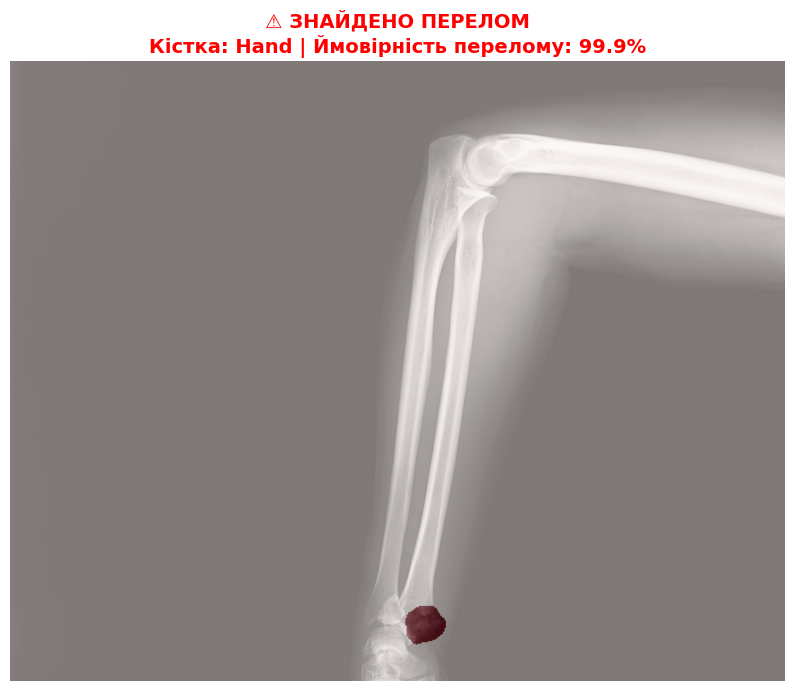

In [24]:
# Визначаємо пристрій
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Завантажуємо класифікатор (працює з розміром 224x224)
print("Завантаження класифікатора...")
classifier = MultiTaskClassifier(num_bone_classes=5).to(device)
# Якщо класифікатор лежить в головній папці, шлях '../multitask_classifier.pth'
classifier.load_state_dict(torch.load('multitask_classifier.pth', map_location=device))
classifier.eval()

# 2. Завантажуємо сегментатор (працює з розміром 512x512)
print("Завантаження сегментатора...")
segmenter = FractureSegmenter(in_channels=3, out_channels=1).to(device)
# Беремо щойно натреновані ваги (вони збереглися в тій же папці, де запущений ноутбук)
segmenter.load_state_dict(torch.load('fracture_segmenter_v5.pth', map_location=device))
segmenter.eval()

# Трансформації для інференсу
transform_cls = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

transform_seg = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

bone_classes = ['Hand', 'Leg', 'Hip', 'Shoulder', 'Mixed']

def predict_and_visualize(image_path, threshold=0.5):
    """Каскадний інференс: Класифікатор -> Сегментатор (якщо є перелом)"""

    # Завантаження оригінального зображення
    img = cv2.imread(image_path)
    if img is None:
        print(f"Помилка: не знайдено файл {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_size = img_rgb.shape[:2] # Зберігаємо оригінальні розміри

    # Підготовка тензорів
    tensor_cls = transform_cls(image=img_rgb)['image'].unsqueeze(0).to(device)
    tensor_seg = transform_seg(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        # --- ЕТАП 1: Скринінг ---
        logits_bone, logits_fracture = classifier(tensor_cls)
        prob_fracture = torch.sigmoid(logits_fracture).item()

        # Визначаємо кістки (беремо ті, де ймовірність > 50%, або максимальну)
        probs_bone = torch.sigmoid(logits_bone).squeeze().cpu().numpy()
        detected_bones = [bone_classes[i] for i, p in enumerate(probs_bone) if p > 0.5]
        if not detected_bones:
            detected_bones = [bone_classes[np.argmax(probs_bone)]]

        mask_resized = None
        is_fractured = prob_fracture > threshold

        # --- ЕТАП 2: Деталізація ---
        if is_fractured:
            logits_mask = segmenter(tensor_seg)
            mask_prob = torch.sigmoid(logits_mask).squeeze().cpu().numpy()
            mask_binary = (mask_prob > 0.5).astype(np.uint8)

            # Розтягуємо знайдену маску назад до розмірів оригінального знімка
            mask_resized = cv2.resize(mask_binary, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)

    # --- ВІЗУАЛІЗАЦІЯ ---
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    title_info = f"Кістка: {', '.join(detected_bones)} | Ймовірність перелому: {prob_fracture:.1%}"

    if is_fractured and mask_resized is not None:
        # Накладаємо червону маску
        plt.imshow(mask_resized, cmap='Reds', alpha=0.5)
        plt.title(f"⚠️ ЗНАЙДЕНО ПЕРЕЛОМ\n{title_info}", color='red', fontsize=14, fontweight='bold')
    else:
        plt.title(f"✅ НОРМА (Без перелому)\n{title_info}", color='green', fontsize=14, fontweight='bold')

    plt.axis('off')
    plt.show()

# ТЕСТУЄМО!
# Вибираємо випадковий знімок з переломом (можеш підставити будь-який інший)
test_image = '../data/FracAtlas/images/Fractured/IMG0000025.jpg'
predict_and_visualize(test_image)